C:\Users\raulo\AppData\Local\Temp\ipykernel_23176\180433478.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_2 = yfinance.download("AAPL", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


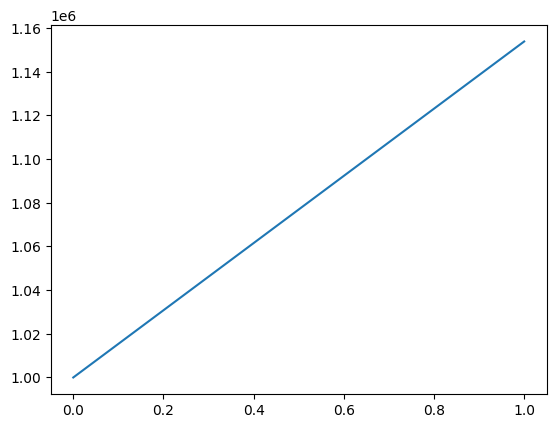

In [ ]:
# Backtesting


data_2 = yfinance.download("AAPL", start="2020-01-01", end="2025-01-01")

data = pd.DataFrame()
data['Close'] = data_2.Close
data['High'] = data_2.High
data['Low'] = data_2.Low
data['Open'] = data_2.Open
#constants
COM = 0.125/100
#Variables
cash = 1_000_000
active_long_positions = []
active_short_positions = []
portfolio_value = [cash]

#Hyperparameters
rsi_lower = 30
rsi_upper = 70
rsi_window = 11
n_shares = 800
sl = 0.05
tp = 0.05

rsi_ind = ta.momentum.RSIIndicator(data.Close, window = rsi_window)
data['rsi'] = rsi_ind.rsi()

data = data.dropna()

for i, row in data.iterrows():
    #Risk management
    #Close Long Positions
    for pos in active_long_positions.copy():
        value = row.Close * n_shares
        #Closing SL
        if value < pos['sl']:
            #print(f"Closing position at {row.Close} with value {value}")
            cash += row.Close * n_shares * (1-COM)
            active_long_positions.remove(pos)
        #Closing TP
        if value > pos['tp']:
            #print(f"Closing position at {row.Close} with value {value}")
            cash += row.Close * n_shares * (1-COM)
            active_long_positions.remove(pos)


    #Trading signals
    buy_signal = row.rsi < rsi_lower
    sell_signal = row.rsi > rsi_upper

    if buy_signal:
        total_cost = row.Close*n_shares*(1+COM)
        #check if we have enough cash
        if cash > total_cost:
            cash -= total_cost
            active_long_positions.append({
                "type": "long",
                "n_shares": n_shares,
                "bought_at":row.Close,
                "sl": row.Close * n_shares * (1-sl),
                "tp": row.Close * n_shares * (1+tp)
            })
    #Portfolio value
    long_vals = len(active_long_positions) * n_shares * row.Close
    #short_vals = ...
portfolio_value.append(long_vals + cash) # Add short values here when implemented
plt.plot(portfolio_value)

In [2]:
pip install optuna

  Using cached optuna-4.7.0-py3-none-any.whl.metadata (17 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
Using cached optuna-4.7.0-py3-none-any.whl (413 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 12.0 MB/s eta 0:00:00
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached mako-1.3.10-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
import yfinance
import pandas as pd
import ta
import matplotlib.pyplot as plt 
import optuna

In [9]:
data_2 = yfinance.download("AAPL", start="2020-01-01", end="2025-01-01")
data = pd.DataFrame()
data['Close'] = data_2.Close
data['High'] = data_2.High
data['Low'] = data_2.Low
data['Open'] = data_2.Open
def objective(trial, data):
    data = data.copy()
    #constants
    COM = 0.125/100
    #Variables
    cash = 1_000_000
    active_long_positions = []
    active_short_positions = []
    portfolio_value = [cash]

    #Hyperparameters
    rsi_lower = trial.suggest_int("rsi_lower", 10, 40)
    rsi_upper = 70
    rsi_window = trial.suggest_int("rsi_window", 5, 80)
    n_shares = trial.suggest_categorical("n_shares", [100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800])
    sl = trial.suggest_float("sl", 0.01, 0.12)
    tp = trial.suggest_float("tp", 0.01, 0.12)

    rsi_ind = ta.momentum.RSIIndicator(data.Close, window = rsi_window)
    data['rsi'] = rsi_ind.rsi()

    data = data.dropna()

    for i, row in data.iterrows():
        #Risk management
        #Close Long Positions
        for pos in active_long_positions.copy():
            value = row.Close * n_shares
            #Closing SL
            if value < pos['sl']:
                #print(f"Closing position at {row.Close} with value {value}")
                cash += row.Close * n_shares * (1-COM)
                active_long_positions.remove(pos)
            #Closing TP
            if value > pos['tp']:
                #print(f"Closing position at {row.Close} with value {value}")
                cash += row.Close * n_shares * (1-COM)
                active_long_positions.remove(pos)


        #Trading signals
        buy_signal = row.rsi < rsi_lower
        sell_signal = row.rsi > rsi_upper

        if buy_signal:
            total_cost = row.Close*n_shares*(1+COM)
            #check if we have enough cash
            if cash > total_cost:
                cash -= total_cost
                active_long_positions.append({
                    "type": "long",
                    "n_shares": n_shares,
                    "bought_at":row.Close,
                    "sl": row.Close * n_shares * (1-sl),
                    "tp": row.Close * n_shares * (1+tp)
                })
        #Portfolio value
        long_vals = len(active_long_positions) * n_shares * row.Close
        #short_vals = ...
        portfolio_value.append(long_vals + cash) 
    return portfolio_value[-1]

C:\Users\raulo\AppData\Local\Temp\ipykernel_19280\96425930.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_2 = yfinance.download("AAPL", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [10]:
study = optuna.create_study(direction="maximize")
study.optimize(lambda x:objective(x, data), n_trials=500)
study.best_params

[I 2026-02-10 21:49:25,894] A new study created in memory with name: no-name-97953e7d-b58f-40e6-9735-4ae42ff5ac70
[I 2026-02-10 21:49:25,972] Trial 0 finished with value: 1000000.0 and parameters: {'rsi_lower': 19, 'rsi_window': 26, 'n_shares': 500, 'sl': 0.11741624123372664, 'tp': 0.015683647377639894}. Best is trial 0 with value: 1000000.0.
[I 2026-02-10 21:49:26,049] Trial 1 finished with value: 1000000.0 and parameters: {'rsi_lower': 11, 'rsi_window': 50, 'n_shares': 350, 'sl': 0.08534368944115164, 'tp': 0.032172234644435034}. Best is trial 0 with value: 1000000.0.
[I 2026-02-10 21:49:26,131] Trial 2 finished with value: 1000000.0 and parameters: {'rsi_lower': 19, 'rsi_window': 32, 'n_shares': 350, 'sl': 0.04478741316030219, 'tp': 0.046721247374669775}. Best is trial 0 with value: 1000000.0.
[I 2026-02-10 21:49:26,210] Trial 3 finished with value: 1000000.0 and parameters: {'rsi_lower': 31, 'rsi_window': 70, 'n_shares': 700, 'sl': 0.019449611475449262, 'tp': 0.012808967627385304}. 

{'rsi_lower': 40,
 'rsi_window': 8,
 'n_shares': 800,
 'sl': 0.117909071871612,
 'tp': 0.0874080194287371}